# V1DD stimulus metrics — access

How to load the per-ROI tuning and responsiveness tables, what each column means, and how
much to trust it.

Every V1DD two-photon session, 25 in all, was shown the same six stimuli. For each
segmented cell this asset records how it responded: what orientation it prefers, which
natural scene drives it hardest, whether the surround suppresses it, where its receptive
field sits on the screen. **39,407 ROIs**, spanning cortical depths from 50 to 514 µm.

| family | prefix | what it tells you |
|---|---|---|
| drifting gratings, full field | `dgf_` | orientation and direction tuning, full screen |
| drifting gratings, windowed | `dgw_` | the same through a small aperture |
| surround suppression | `ssi*` | how much the surround costs |
| natural images | `ni_` | selectivity across 118 scenes |
| natural images 12 | `ni12_` | the same, 12 scenes with 40 repeats each |
| natural movie | `nm_` | reliability across repeats of a clip |
| receptive fields | `*_rf_*` | where on the screen the cell responds |

Nothing here writes anything. It reads the asset and plots it.

In [1]:
import json
import os
import sys
from os.path import join as pjoin

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

for _candidate in [pjoin("..", "utils"), pjoin("code", "utils"), "utils"]:
    if os.path.isdir(_candidate):
        sys.path.append(os.path.abspath(_candidate))
        break
from paths import resolve_data_root, resolve_dataset_dir      # noqa: E402
from provenance import latest_run                             # noqa: E402

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## Loading

The asset ships as one **wide table** — `stimulus_metrics_M409828.feather`, one row per
ROI with every family's columns side by side — plus seven per-family CSVs holding the same
numbers. Use the feather unless you specifically want one family.

Two things about the CSVs are worth knowing before you read them yourself:

* **`volume` must be read as a string.** Volumes are labelled 1–9 and a–f across the wider
  project; pandas will infer `int` for an all-numeric column and then fail to join against
  anything that kept them as text.
* **`float_precision="round_trip"`.** Pandas' default CSV parser is off by one unit in the
  last place, so a table read with defaults will not compare equal to the feather even
  though the files agree. It matters only if you are checking one against the other.

In [2]:
ASSET = "409828_V1DD_stimulus_metrics"
data_root = resolve_data_root(ASSET)
asset_dir = (resolve_dataset_dir(ASSET, root=data_root, required=False)
             or latest_run("/results", ASSET) or latest_run("/scratch", ASSET))
if asset_dir is None:
    raise FileNotFoundError(f"could not find {ASSET} under {data_root}, /results or /scratch")

metrics = pd.read_feather(pjoin(asset_dir, "stimulus_metrics_M409828.feather"))
prov = json.load(open(pjoin(asset_dir, "stimulus_metrics_provenance.json")))

print(f"{asset_dir}")
print(f"  {len(metrics):,} ROIs x {len(metrics.columns)} columns")
print(f"  {prov['n_sessions']} sessions, {prov['n_planes']} planes, mouse {prov['mouse']}")
print(f"  built {prov['generated_utc']}  seed {prov['seed']}  complete={prov['complete_asset']}")
display(metrics.head(3))

# The per-family CSVs, if you want one family on its own:
#   pd.read_csv(pjoin(asset_dir, "drifting_gratings_windowed_M409828.csv"),
#               dtype={"volume": str}, float_precision="round_trip")

/opt/conda/lib/python3.12/site-packages/pandas/io/feather_format.py:123: FutureWarning: pyarrow.feather.read_feather is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  return feather.read_feather(


/root/capsule/data/409828_V1DD_stimulus_metrics
  39,407 ROIs x 57 columns
  25 sessions, 150 planes, mouse M409828
  built 2026-08-17T02:38:39+00:00  seed 0  complete=True


,roi_unique_id,roi_key,mouse,column,volume,plane,roi,depth_um,pika_roi_confidence,dgf_dsi,dgf_frac_responsive_trials,dgf_gosi,dgf_is_responsive,dgf_lifetime_sparseness,dgf_osi,dgf_preferred_dir,dgf_preferred_sf,dgf_pref_dir_mean,dgw_dsi,dgw_frac_responsive_trials,dgw_gosi,dgw_is_responsive,dgw_lifetime_sparseness,dgw_osi,dgw_preferred_dir,dgw_preferred_sf,dgw_pref_dir_mean,ssi,ssi_avg,ssi_avg_at_pref_sf,ssi_running,ssi_running_avg_at_pref_sf,ssi_stationary,ssi_stationary_avg_at_pref_sf,ssi_tuning_fit,ni_frac_responsive_trials,ni_lifetime_sparseness,ni_pref_img,ni_pref_response,ni_z_score,ni12_frac_responsive_trials,ni12_lifetime_sparseness,ni12_pref_img,ni12_pref_response,ni12_z_score,nm_frac_responsive_trials,nm_lifetime_sparseness,nm_pref_img,nm_pref_response,nm_z_score,has_rf_on,has_rf_off,has_rf_on_or_off,azimuth_rf_on,altitude_rf_on,azimuth_rf_off,altitude_rf_off
0,M409828_1_0_0,M409828_21_0_0,M409828,2,1,0,0,50.0,0.916531,0.170565,0.750000,0.062210,1.0,0.641349,0.141176,60.0,0.04,102.323683,0.473136,0.666667,0.130354,1.0,0.493566,0.287317,60.0,0.04,34.685937,0.169997,0.178505,0.138997,0.714269,0.338794,NaN,-0.222836,0.225285,1.0,0.949566,95,0.013219,8.464313,1.0,0.944241,6,0.002741,2.872878,1.00,0.938732,128,0.114384,102.299766,False,False,False,NaN,NaN,NaN,NaN
1,M409828_1_0_1,M409828_21_0_1,M409828,2,1,0,1,50.0,0.916861,0.401002,0.666667,0.055298,1.0,0.559182,0.190679,240.0,0.04,211.967237,0.171647,0.500000,0.156037,1.0,0.593273,0.428314,90.0,0.04,188.487263,0.315031,0.090188,0.069426,0.456289,0.154399,0.13102,-0.082297,0.107733,1.0,0.955998,32,0.306946,208.441292,1.0,0.849543,32,0.205877,313.287598,0.25,0.931233,2700,0.029581,25.651150,True,True,True,-13.95,-13.95,-13.95,-13.95
2,M409828_1_0_2,M409828_21_0_2,M409828,2,1,0,2,50.0,0.913705,0.068572,0.250000,0.211209,0.0,0.697208,0.327968,210.0,0.08,42.966658,0.670839,0.500000,0.092131,1.0,0.623673,0.277535,330.0,0.04,301.653299,0.125412,-0.120298,0.027518,-0.215105,0.109958,NaN,-0.121178,0.149692,1.0,0.952706,36,0.011945,5.575515,1.0,0.941636,2,0.004125,3.450697,0.50,0.931351,1383,0.048518,31.370760,True,False,True,-23.25,-13.95,NaN,NaN


## Identifying a cell

Four columns identify an ROI: **`column`, `volume`, `plane`, `roi`**. Join on all four.

`column` is a cortical location, `volume` a block of six imaging planes at increasing
depth, `plane` the plane within it. `depth_um` gives the actual imaging depth, which the
other three encode only implicitly, and `pika_roi_confidence` the segmentation confidence
that decides whether an ROI is treated as reliable — see the section below.

There are two identifier strings, and they are not interchangeable. `roi_key` is unique
across the asset. **`roi_unique_id` is not** — it omits the column, so it collides between
cortical locations: 13,555 distinct strings for 39,407 rows. It exists because earlier
tables used that format. Do not join on it.

In [3]:
print(f"roi_key       {metrics['roi_key'].nunique():>7,} distinct of {len(metrics):,} rows")
print(f"roi_unique_id {metrics['roi_unique_id'].nunique():>7,} distinct of {len(metrics):,} rows"
      f"   <- collides {len(metrics) / metrics['roi_unique_id'].nunique():.1f}x")
print()
counts = metrics.groupby(["column", "volume"]).size().unstack(fill_value=0)
print("ROIs per session (column x volume)")
display(counts)
depths = metrics.groupby("volume")["depth_um"].agg(["min", "max"]).astype(int)
print(f"depth: {metrics.depth_um.min():.0f}-{metrics.depth_um.max():.0f} um across "
      f"{metrics.depth_um.nunique()} planes")
display(depths.T)

roi_key        39,407 distinct of 39,407 rows
roi_unique_id  13,555 distinct of 39,407 rows   <- collides 2.9x

ROIs per session (column x volume)


volume,1,2,3,4,5
column,,,,,
1,587,2066,2708,2217,965
2,914,1824,2634,2352,906
3,652,1726,1447,1199,474
4,1550,1627,2098,2327,760
5,810,2041,2733,2004,786


depth: 50-514 um across 30 planes


volume,1,2,3,4,5
min,50,146,242,338,434
max,130,226,322,418,514


## How reproducible is each column?

Some of these numbers are properties of the cell; others are thresholds on a random
resampling and would come out somewhat differently on a rerun. That distinction is not
visible in the table, so it is worth stating plainly before you filter on anything.

Three metric families — `frac_responsive_trials`, `is_responsive` and `z_score` — compare
each ROI against a null distribution bootstrapped from its own spontaneous activity. The
asset was built with a fixed seed, so it is reproducible exactly; but running with a
*different* seed gives a different draw, and the spread between two seeds is a fair
estimate of how much of each number is noise.

Measured on the coregistered sessions, correlation between two independent seeds:

| column | seed-to-seed r | how to read it |
|---|---|---|
| `ni_frac_responsive_trials` | **0.77** | a soft indicator, not a per-cell fact |
| `ni12_frac_responsive_trials` | **0.77** | same |
| `has_rf_on` / `has_rf_off` | 0.94 | ~2–3 % of cells flip between seeds |
| `dgw_is_responsive` | 0.95 | a threshold on a bootstrap |
| `dgf_frac_responsive_trials` | 0.98 | |
| `ni_z_score`, `ni12_z_score` | 0.9997 | stable; read at face value |

Everything not listed — `osi`, `dsi`, `gosi`, `lifetime_sparseness`, `preferred_dir`,
`preferred_sf`, `pref_img`, `pref_response`, all the `ssi*` columns and the receptive-field
centres — is deterministic given the data and reproduces exactly.

The practical consequence: a hard cut like `ni_frac_responsive_trials > 0.5` selects a
population that is roughly a quarter arbitrary. Prefer the deterministic columns for
selection where you can, and treat the responsiveness flags as weak evidence to be pooled
rather than as labels.

## Low-confidence ROIs, and how to find them

Segmentation assigns every ROI a confidence, and cells below threshold are treated as
unreliable. The asset handles them **inconsistently, and does not label them**, so this is
worth knowing before you take a population average.

For a low-confidence ROI the columns that depend on picking a preferred condition are
suppressed — `preferred_dir`, `preferred_sf`, all eight `ssi*`, and every receptive-field
column — but the ones computed directly from the responses are not: `osi`, `dsi`, `gosi`,
`lifetime_sparseness`, and everything under `ni_`, `ni12_` and `nm_` are populated as
usual.

`pika_roi_confidence` carries the segmentation confidence, and **ROIs at or below 0.5 are
the unreliable ones**:

```python
low_confidence = metrics["pika_roi_confidence"] <= 0.5
```

On assets built before that column existed the suppression itself is the fallback —
`metrics["dgw_preferred_dir"].isna()` identifies exactly the same rows. The cell below
uses whichever is available.

They are **not** spread evenly. In this asset every one of them falls in a single session,
which is a property of that session's segmentation rather than of the analysis — so an
average taken across all ROIs is weighted by one session's data quality unless you exclude
them.

In [4]:
if "pika_roi_confidence" in metrics.columns:
    low_conf = metrics["pika_roi_confidence"] <= 0.5
    source = "pika_roi_confidence <= 0.5"
else:
    low_conf = metrics["dgw_preferred_dir"].isna()
    source = "inferred from the suppressed preferred condition (no confidence column)"
print(f"{low_conf.sum():,} of {len(metrics):,} ROIs ({low_conf.mean():.2%}) are low "
      f"confidence   [{source}]")
by_session = pd.crosstab(metrics["column"], metrics["volume"], low_conf,
                         aggfunc="sum").fillna(0).astype(int)
print()
print("low-confidence ROIs per session (column x volume)")
display(by_session)
worst = metrics[low_conf].groupby(["column", "volume"]).size().idxmax()
n_worst = int(low_conf.sum())
total_worst = int(((metrics["column"] == worst[0]) & (metrics["volume"] == worst[1])).sum())
print(f"all of them are in column {worst[0]} volume {worst[1]}: "
      f"{n_worst:,} of that session's {total_worst:,} ROIs ({n_worst/total_worst:.0%})")
print()
print("what is suppressed for them, and what is not:")
for c in ["dgw_preferred_dir", "ssi", "has_rf_on_or_off", "dgw_osi", "dgw_dsi",
          "ni_pref_response", "nm_lifetime_sparseness"]:
    v = metrics.loc[low_conf, c]
    frac = v.isna().mean() if v.dtype != bool else 1 - v.mean()
    print(f"  {c:<26} {'suppressed' if frac > 0.99 else 'populated':<12} "
          f"({frac:.0%} NaN/False in this subset)")

1,038 of 39,407 ROIs (2.63%) are low confidence   [pika_roi_confidence <= 0.5]

low-confidence ROIs per session (column x volume)


volume,1,2,3,4,5
column,,,,,
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,1038,0,0,0,0
5,0,0,0,0,0


all of them are in column 4 volume 1: 1,038 of that session's 1,550 ROIs (67%)

what is suppressed for them, and what is not:
  dgw_preferred_dir          suppressed   (100% NaN/False in this subset)
  ssi                        suppressed   (100% NaN/False in this subset)
  has_rf_on_or_off           suppressed   (100% NaN/False in this subset)
  dgw_osi                    populated    (0% NaN/False in this subset)
  dgw_dsi                    populated    (0% NaN/False in this subset)
  ni_pref_response           populated    (0% NaN/False in this subset)
  nm_lifetime_sparseness     populated    (0% NaN/False in this subset)


## Responsiveness across stimuli

Cells are not uniformly responsive: a cell that ignores gratings may respond well to
natural scenes. `is_responsive` (gratings) and `frac_responsive_trials` (everything else)
measure this per family.

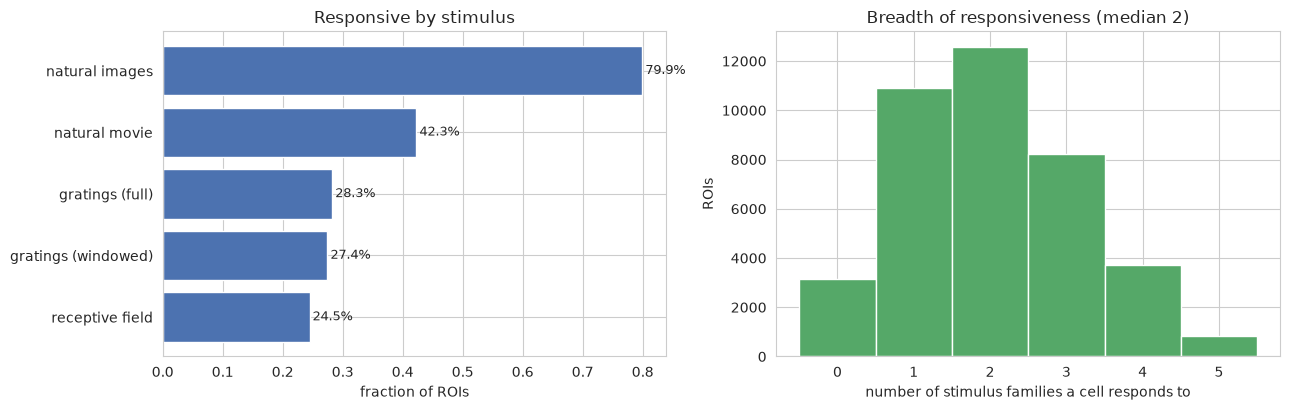

In [5]:
resp = pd.DataFrame({
    "gratings (full)": metrics["dgf_is_responsive"] > 0.5,
    "gratings (windowed)": metrics["dgw_is_responsive"] > 0.5,
    "natural images": metrics["ni_frac_responsive_trials"] > 0.25,
    "natural movie": metrics["nm_frac_responsive_trials"] > 0.5,
    "receptive field": metrics["has_rf_on_or_off"].astype(bool),
})
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
frac = resp.mean().sort_values()
axes[0].barh(frac.index, frac.values, color="#4C72B0")
axes[0].set_xlabel("fraction of ROIs")
axes[0].set_title("Responsive by stimulus")
for i, v in enumerate(frac.values):
    axes[0].text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)

n_families = resp.sum(axis=1)
axes[1].hist(n_families, bins=np.arange(-0.5, 6.5), color="#55A868", edgecolor="white")
axes[1].set_xlabel("number of stimulus families a cell responds to")
axes[1].set_ylabel("ROIs")
axes[1].set_title(f"Breadth of responsiveness (median {int(n_families.median())})")
plt.tight_layout(); plt.show()
# Left: how often each stimulus drives a cell at all. Right: how many of the five a given
# cell responds to -- the tail at zero is cells this stimulus set never engaged.

## Orientation and direction tuning

From the grating responses: `osi` and `dsi` compare the preferred direction against the
orthogonal and opposite ones, `gosi` is a vector-sum version over all twelve directions,
and `lifetime_sparseness` says how concentrated the response is across conditions.
`preferred_dir` is the best of the twelve sampled directions; `pref_dir_mean` comes from a
fitted curve and is not restricted to those twelve.

**`preferred_dir` and `preferred_sf` are NaN** wherever no preferred condition could be
established — in practice the low-confidence ROIs from the previous section, and in
principle also any cell with no finite response anywhere. That is deliberate: reporting
direction 0 for a cell with nothing behind it would look like data. Drop them before
histogramming.

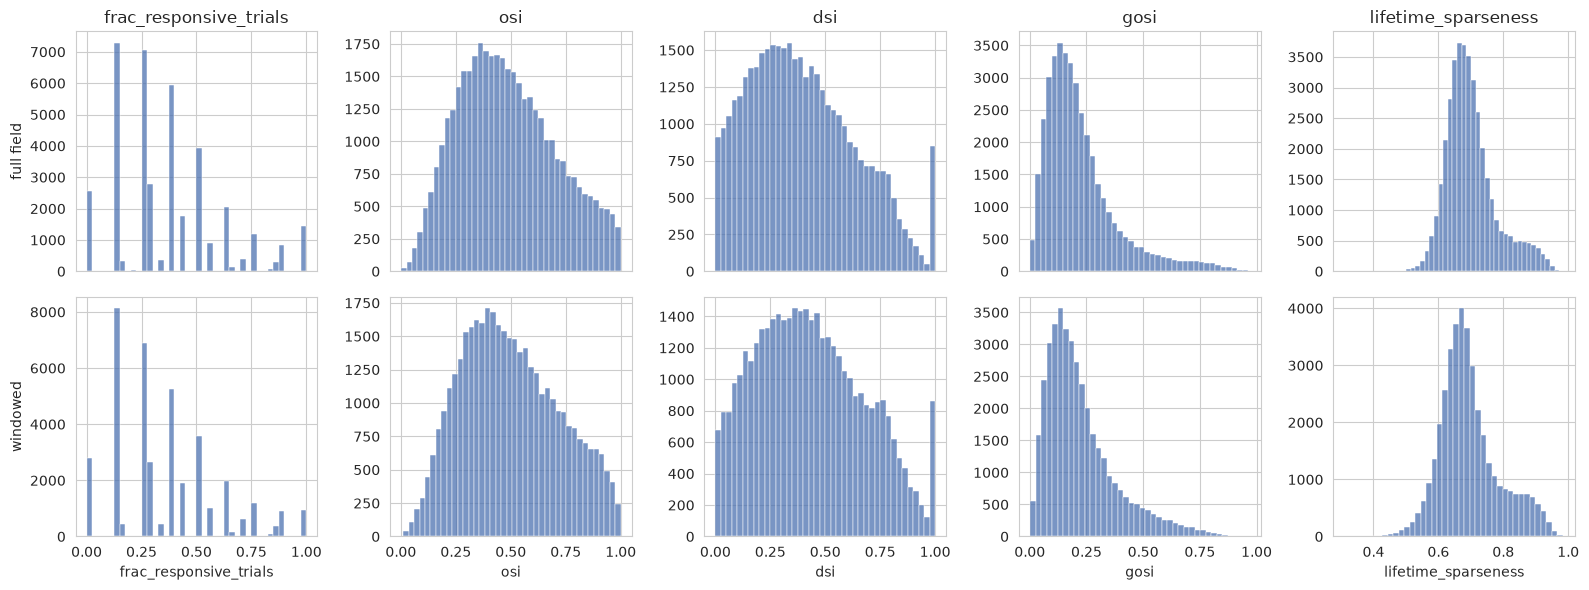

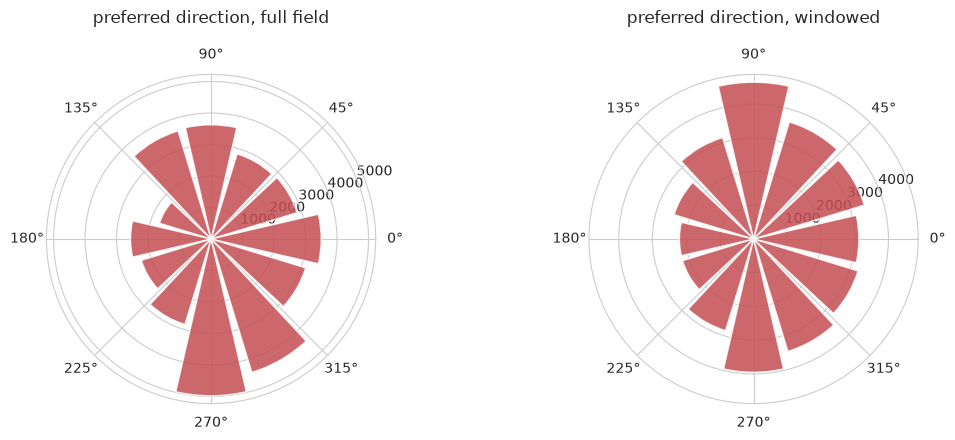

1,038 ROIs have no preferred direction -- the low-confidence ones above


In [6]:
PLOT_VARS = ["frac_responsive_trials", "osi", "dsi", "gosi", "lifetime_sparseness"]
fig, axes = plt.subplots(2, len(PLOT_VARS), figsize=(16, 6), sharex="col")
for row, (pre, label) in enumerate([("dgf_", "full field"), ("dgw_", "windowed")]):
    for col, var in enumerate(PLOT_VARS):
        ax = axes[row, col]
        sns.histplot(metrics[pre + var].dropna(), ax=ax, bins=40, color="#4C72B0")
        ax.set_ylabel(label if col == 0 else "")
        ax.set_xlabel(var if row == 1 else "")
        ax.set_title(var if row == 0 else "")
plt.tight_layout(); plt.show()
# Two rows, same five metrics: full-field gratings above, windowed below. The windowed
# stimulus drives most cells harder, which is what surround suppression quantifies.

n_nan = metrics["dgw_preferred_dir"].isna().sum()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5),
                         subplot_kw={"projection": "polar"})
for ax, pre, label in [(axes[0], "dgf_", "full field"), (axes[1], "dgw_", "windowed")]:
    d = metrics[pre + "preferred_dir"].dropna()
    counts = d.value_counts().sort_index()
    theta = np.deg2rad(counts.index.to_numpy())
    ax.bar(theta, counts.to_numpy(), width=np.deg2rad(26), color="#C44E52", alpha=0.85)
    ax.set_theta_zero_location("E")
    ax.set_title(f"preferred direction, {label}", pad=18)
plt.tight_layout(); plt.show()
print(f"{n_nan:,} ROIs have no preferred direction -- the low-confidence ones above")
# Cardinal directions are over-represented -- a real feature of mouse V1, not an artefact
# of the twelve sampled directions.

## Surround suppression

The windowed and full-field gratings differ only in the size of the patch, so comparing a
cell's response to the two measures what the surround does to it. The index is
`(W − F) / (W + F)`: **positive means the surround suppresses**, zero means it makes no
difference, negative means the larger stimulus drives the cell harder.

The reference condition is always the *windowed* stimulus's preferred direction and
spatial frequency, and the full-field response is read at that same condition rather than
at its own preferred one — the question is what the surround does to a given drive.

Eight variants, differing in what is averaged and whether the animal was moving:

| column | definition |
|---|---|
| `ssi` | preferred windowed condition, full-field response at that condition |
| `ssi_avg` | averaged over direction *and* spatial frequency |
| `ssi_avg_at_pref_sf` | averaged over direction, at the preferred spatial frequency |
| `ssi_running` | as `ssi`, running trials only (> 1 cm/s) |
| `ssi_stationary` | as `ssi`, stationary trials only (< 1 cm/s) |
| `ssi_running_avg_at_pref_sf` | averaged over direction at preferred SF, running |
| `ssi_stationary_avg_at_pref_sf` | the same, stationary |
| `ssi_tuning_fit` | from the fitted tuning curves rather than measured responses |

Three details that determine how often each is populated, and are not obvious from the
names:

* Running and stationary use **strict** inequalities on both sides, so a trial at exactly
  1 cm/s counts as neither.
* `ssi_running` and `ssi_stationary` require **at least three** qualifying trials in both
  stimuli. The `*_avg_at_pref_sf` variants have no such minimum — which is why they are
  populated far more often, and why the two are not interchangeable.
* `ssi_tuning_fit` evaluates the fitted curve including its baseline offset, while the
  preferred direction feeding it is chosen with the baseline subtracted.

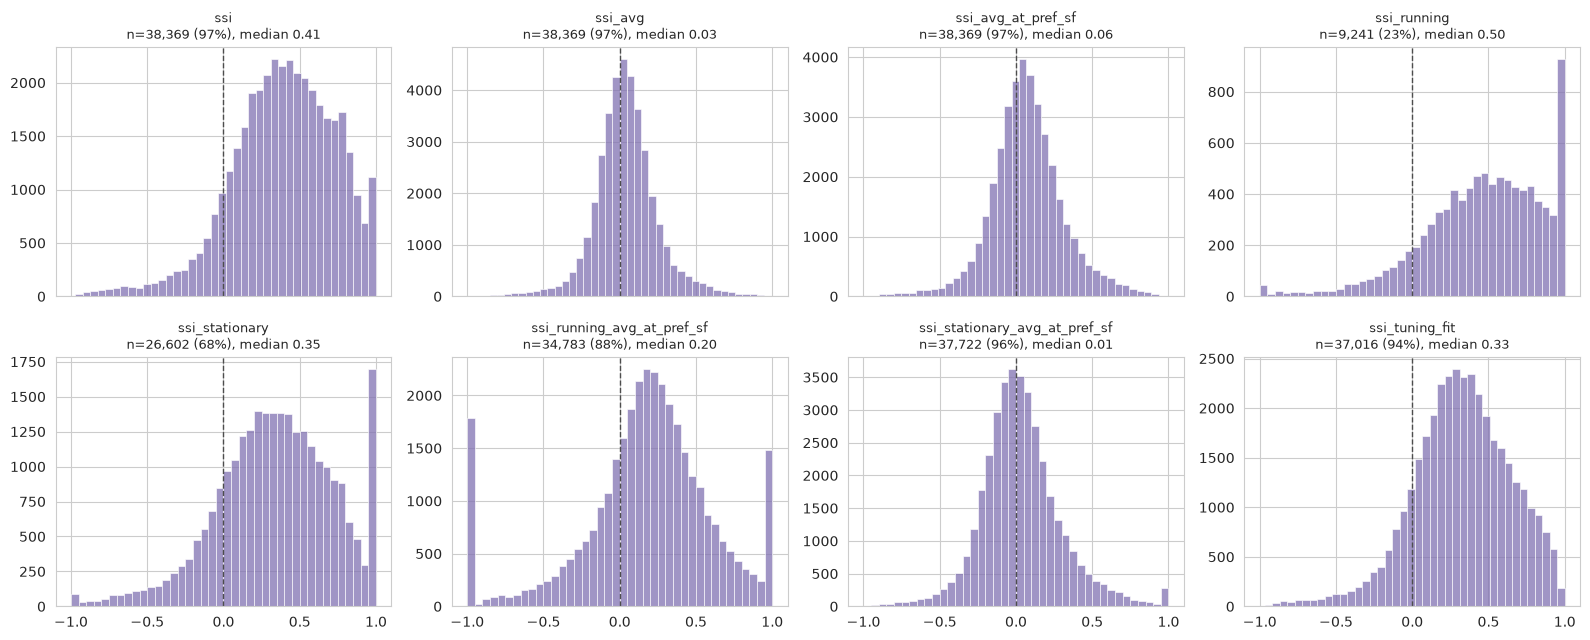

In [7]:
SSI_COLS = ["ssi", "ssi_avg", "ssi_avg_at_pref_sf", "ssi_running", "ssi_stationary",
            "ssi_running_avg_at_pref_sf", "ssi_stationary_avg_at_pref_sf", "ssi_tuning_fit"]
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5), sharex=True)
for ax, c in zip(axes.ravel(), SSI_COLS):
    v = metrics[c].dropna()
    sns.histplot(v, ax=ax, bins=40, color="#8172B2")
    ax.axvline(0, color="0.3", lw=1, ls="--")
    ax.set_title(f"{c}\nn={len(v):,} ({len(v)/len(metrics):.0%}), median {v.median():.2f}",
                 fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()
# All eight on the same axis. The dashed line is zero -- no suppression. Note how the n
# differs: the two with a three-trial minimum are populated far less often than their
# *_avg_at_pref_sf counterparts, which is the trap described above.

## Receptive fields

From locally sparse noise on an 8 × 14 grid: for each screen position, how often a bright
(ON) or dark (OFF) patch there produced a response above the cell's own spontaneous
threshold. A cell "has" a receptive field if at least one position survived; the centre is
the centroid of those positions.

Centres are in **degrees of visual angle** on the true screen scale, spanning ±32.55° in
altitude and ±60.45° in azimuth. If you compare against tables distributed before this
asset, note that those used a compressed scale — ±28.48° and ±56.13° — from a mapping that
divided by the number of pixels rather than the number of gaps between them. The two differ
by a constant factor of `n/(n−1)`.

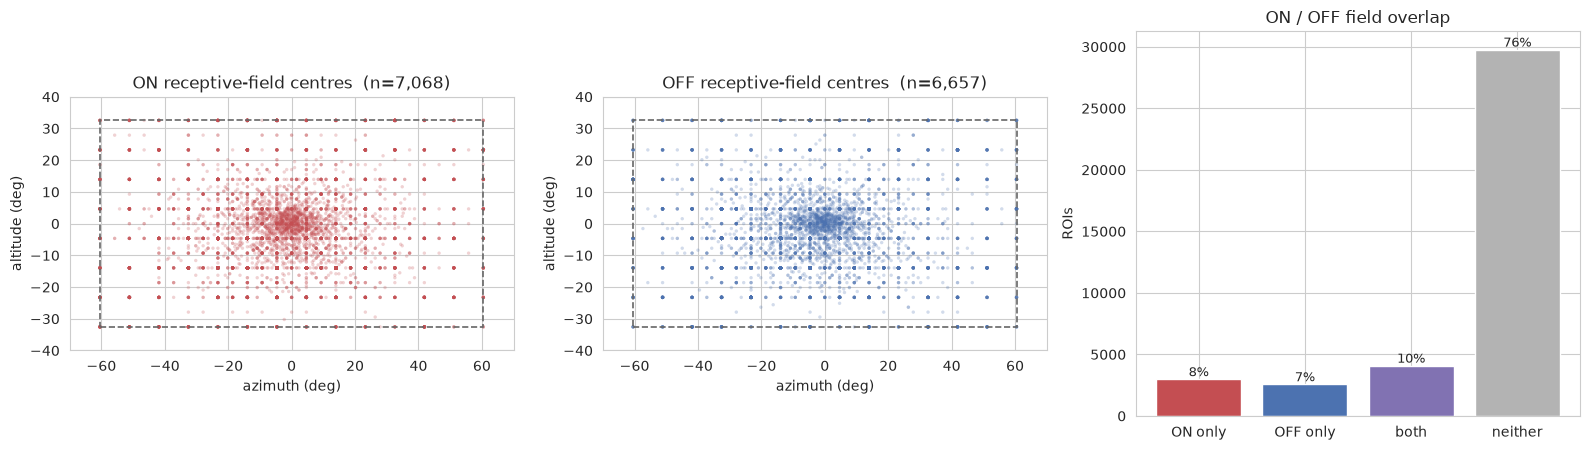

In [8]:
ALT_LIM, AZI_LIM = 32.55, 60.45
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (azi, alt, label, colour) in zip(axes[:2], [
        ("azimuth_rf_on", "altitude_rf_on", "ON", "#C44E52"),
        ("azimuth_rf_off", "altitude_rf_off", "OFF", "#4C72B0")]):
    d = metrics[[azi, alt]].dropna()
    ax.scatter(d[azi], d[alt], s=6, alpha=0.25, color=colour, edgecolors="none")
    ax.add_patch(plt.Rectangle((-AZI_LIM, -ALT_LIM), 2 * AZI_LIM, 2 * ALT_LIM,
                               fill=False, ec="0.4", lw=1.2, ls="--"))
    ax.set_xlim(-70, 70); ax.set_ylim(-40, 40); ax.set_aspect("equal")
    ax.set_xlabel("azimuth (deg)"); ax.set_ylabel("altitude (deg)")
    ax.set_title(f"{label} receptive-field centres  (n={len(d):,})")

overlap = pd.Series({
    "ON only": (metrics.has_rf_on & ~metrics.has_rf_off).sum(),
    "OFF only": (~metrics.has_rf_on & metrics.has_rf_off).sum(),
    "both": (metrics.has_rf_on & metrics.has_rf_off).sum(),
    "neither": (~metrics.has_rf_on_or_off).sum()})
axes[2].bar(overlap.index, overlap.values, color=["#C44E52", "#4C72B0", "#8172B2", "0.7"])
axes[2].set_ylabel("ROIs"); axes[2].set_title("ON / OFF field overlap")
for i, v in enumerate(overlap.values):
    axes[2].text(i, v, f"{v/len(metrics):.0%}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()
# Dashed rectangle is the screen. Centres cluster rather than filling it, because these
# are all one retinotopic location imaged repeatedly -- the spread is receptive-field
# scatter within a cortical column, not coverage of the visual field.

## Depth

`depth_um` is the imaging depth of the plane, 50–514 µm in 16 µm steps within a volume and
96 µm between volumes. It spans layer 2/3 through layer 5, so it is the natural axis for
asking whether a property varies with cortical depth.

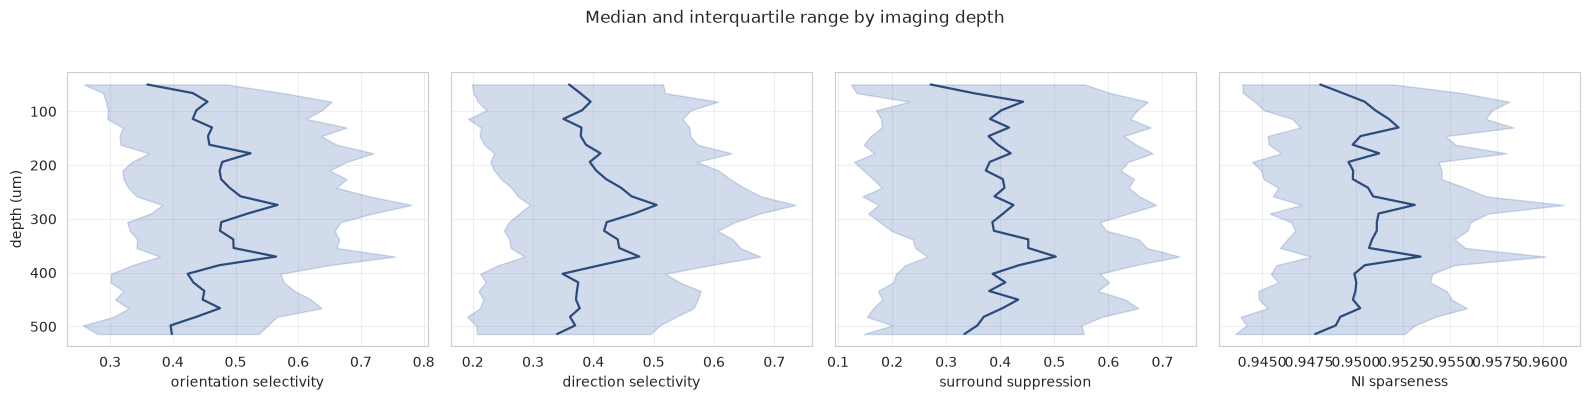

In [9]:
DEPTH_VARS = [("dgw_osi", "orientation selectivity"), ("dgw_dsi", "direction selectivity"),
              ("ssi", "surround suppression"), ("ni_lifetime_sparseness", "NI sparseness")]
fig, axes = plt.subplots(1, len(DEPTH_VARS), figsize=(16, 3.8), sharey=True)
for ax, (col, label) in zip(axes, DEPTH_VARS):
    d = metrics[["depth_um", col]].dropna()
    g = d.groupby("depth_um")[col]
    med, lo, hi = g.median(), g.quantile(0.25), g.quantile(0.75)
    ax.fill_betweenx(med.index, lo, hi, alpha=0.25, color="#4C72B0")
    ax.plot(med.to_numpy(), med.index.to_numpy(), color="#2A4B7C", lw=1.6)
    ax.set_xlabel(label)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("depth (um)")
axes[0].invert_yaxis()
plt.suptitle("Median and interquartile range by imaging depth", y=1.04)
plt.tight_layout(); plt.show()
# Each point is one imaging plane (30 of them). Shaded band is the interquartile range
# across ROIs at that depth, so it shows spread within a plane, not uncertainty in the
# median.

## Optional: merging with the EM coregistration

A subset of these cells has been matched to reconstructed neurons in the electron
microscopy volume, which is what makes it possible to ask whether a cell's tuning relates
to its synaptic partners. That mapping lives in CAVE and needs a token, so this section is
optional — everything above works without it.

**Initialize CAVEclient and input token.** Querying that datastack requires inputing a user authentication token. Follow prompts below.

In [10]:
from caveclient import CAVEclient

# Token Generation and Setup
CAVEclient.setup_token("https://global.em.brain.allentech.org")

mat_version = 1196

# Initialize CAVEclient
client = CAVEclient(datastack_name="v1dd_public", version=mat_version)

/opt/conda/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.2) or chardet (7.6.0)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


Visit https://global.em.brain.allentech.org/sticky_auth/settings/tokens and copy an existing token or create a new one.


Paste your auth token (input will be hidden):  ········
Set all of your datastacks to use this token and server ('Y', recommended), specify individual datastacks ('n'), or finish now ('exit'). (Y/n/exit)  y


All datastacks are configured to use this server address.
You will not need to specify a server address when initializing a client for configured datastacks in the future.
Setup complete!


**Deduplicate the coregistration table before merging.** It contains repeated rows for
some cells, and a merge propagates them, inflating any count you take afterwards.

coregistration: 571 rows -> 565 after deduplication
merged with metrics: 559 ROIs (1.4% of the asset)
  with a receptive field   37.2%
  responsive to gratings   33.3%


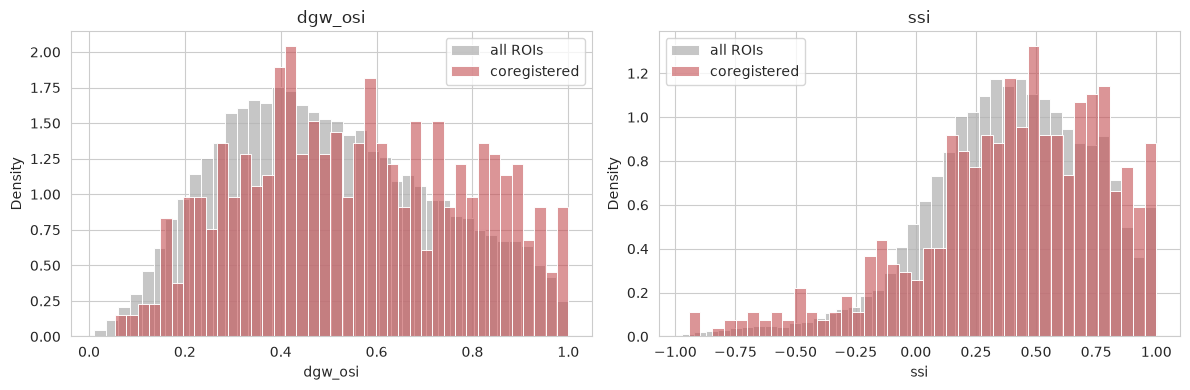

In [11]:
coreg = None
try:
    coreg = client.materialize.query_table("functional_coregistration_manual_2")[
        ["pt_root_id", "column", "volume", "plane", "roi"]]
except Exception as exc:                                       # noqa: BLE001
    print(f"coregistration unavailable ({type(exc).__name__}) -- skipping this section")

if coreg is not None:
    coreg = coreg.astype({"pt_root_id": "int64", "column": int, "volume": str,
                          "plane": int, "roi": int})
    n_raw = len(coreg)
    coreg = coreg.drop_duplicates(["column", "volume", "plane", "roi"])
    print(f"coregistration: {n_raw:,} rows -> {len(coreg):,} after deduplication")

    merged = coreg.merge(metrics, on=["column", "volume", "plane", "roi"], how="inner")
    print(f"merged with metrics: {len(merged):,} ROIs "
          f"({len(merged)/len(metrics):.1%} of the asset)")
    print(f"  with a receptive field   {merged.has_rf_on_or_off.mean():.1%}")
    print(f"  responsive to gratings   {(merged.dgw_is_responsive > 0.5).mean():.1%}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, col in zip(axes, ["dgw_osi", "ssi"]):
        sns.histplot(metrics[col].dropna(), stat="density", bins=40, ax=ax,
                     color="0.7", label="all ROIs")
        sns.histplot(merged[col].dropna(), stat="density", bins=40, ax=ax,
                     color="#C44E52", alpha=0.6, label="coregistered")
        ax.set_title(col); ax.legend()
    plt.tight_layout(); plt.show()
    # Whether the coregistered subset is representative of the whole population -- worth
    # checking before generalising anything measured on it.

## Notes and caveats

**Response windows were inherited, not optimised.** They were chosen for slower calcium
signals; this asset is computed from deconvolved events, which are considerably sparser.
A window suited to one is not obviously right for the other. If you are doing something
sensitive to the exact response magnitude, that is the assumption to question first.

**`pref_img` for the natural movie is approximate.** Frames are 1/30 s apart and the
response window spans several of them, so activity driven by one frame falls inside the
windows of its neighbours. Read it as "around here in the clip", not as an exact frame.

**Receptive fields use ΔF/F; everything else uses deconvolved events.** The receptive-field
method needs a signal smooth enough for a baseline to mean something.

**Only a fraction of sessions are EM-coregistered.** The rest are perfectly good functional
measurements with no synaptic partner to merge against.

How the asset was produced, including every configuration value and the package versions,
is recorded in `stimulus_metrics_provenance.json` beside the tables.